In this notebook, I will fix the TD measurement and covariance matrices. I have a ground truth time-delay and the time-delay used in forecasting was mismatched. This is because there's an additional mass sheet assumed in the forecast, and I assumed a kappa_ext that I didn't keep track of, so without the kappa_ext, if I use the lens model I started with, the ground truth time-delay doesn't match the lens model predicted time-delay.

Collectively, the internal mass sheet and the external convergence act as scaling factors, so in this notebook, I am just going to scale the time-delay measurement mean and covariance by a scalar.

#### sanity checks

In [55]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

(-100.0, 10.0)

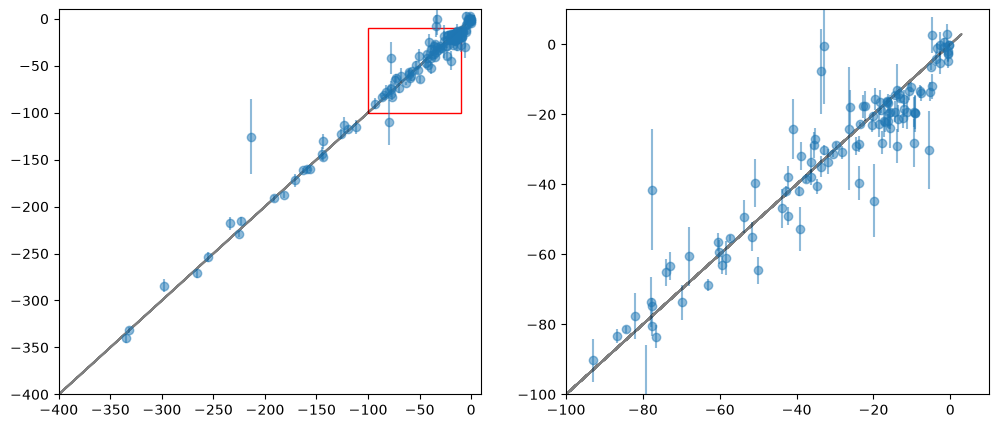

In [56]:
df = pd.read_csv('time_delay_joint_measurements.csv')
fig ,ax = plt.subplots(1, 2, figsize=(12, 5))
# take just the first element of the array in the 'uncertainty' column
unc_values = df['uncertainty'].apply(lambda x: re.findall(r"[-+]?\d*\.\d+|\d+", x)[0]).astype(float)
ax[0].errorbar(df['td01_true'], df['td01'], yerr = unc_values, fmt='o',alpha=0.5)
ax[0].plot(df['td01'], df['td01'], color='black', alpha=0.5)
ax[0].set_xlim(-400, 10)
ax[0].set_ylim(-400, 10)
# draw a box in ax[0] to highlight the region of interest
rect = plt.Rectangle((-100, -100), 90, 90, linewidth=1, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)

ax[1].errorbar(df['td01_true'], df['td01'], yerr = unc_values, fmt='o',alpha=0.5)
ax[1].plot(df['td01'], df['td01'], color='black', alpha=0.5)
ax[1].set_xlim(-100, 10)
ax[1].set_ylim(-100, 10)

In [57]:
df

,cov_scaled,td01,td02,td03,prec_scaled,catalog_idx,td01_true,td02_true,td03_true,uncertainty,relative_uncertainty,relative_error,error_in_sigma,error,error_in_sigma_signed
0,[[30.93789903]],-46.804751,NaN,NaN,[[0.03232282]],deblcdouble653,-43.841759,NaN,NaN,[5.56218474 nan nan],0.126870,[0.0675838 nan nan],[0.53270304 nan nan],[-2.96299272 nan nan],[-0.53270304 nan nan]
1,[[ 6.5535241 4.25373003 4.28016326]\n [ 4.2...,-56.351601,-64.582261,-63.265716,[[ 0.24285476 -0.06887508 -0.06975867]\n [-0.0...,deblcquad134,-60.424795,-67.846857,-68.353976,[2.55998518 3.57646433 3.57053392],0.042366,[0.06740932 0.04811712 0.07443986],[1.59110067 0.91279968 1.42506989],[4.07319413 3.2645955 5.08826039],[1.59110067 0.91279968 1.42506989]
2,[[14.8231629]],-22.657524,NaN,NaN,[[0.06746199]],deblcdouble91,-18.445097,NaN,NaN,[3.85008609 nan nan],0.208732,[0.22837654 nan nan],[1.09411249 nan nan],[-4.21242729 nan nan],[-1.09411249 nan nan]
3,[[25.39360532]],-17.987086,NaN,NaN,[[0.03937999]],deblcdouble23,-26.201463,NaN,NaN,[5.03920681 nan nan],0.192325,[0.31350833 nan nan],[1.63009325 nan nan],[8.21437702 nan nan],[1.63009325 nan nan]
4,[[0.74609105]],-14.424669,NaN,NaN,[[1.34031899]],deblcdouble112,-14.414341,NaN,NaN,[0.86376562 nan nan],0.059924,[0.00071656 nan nan],[0.01195776 nan nan],[-0.0103287 nan nan],[-0.01195776 nan nan]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,[[28.83820446]],-19.705418,NaN,NaN,[[0.03467622]],deblcdouble553,-9.310776,NaN,NaN,[5.37012146 nan nan],0.576764,[1.11640995 nan nan],[1.93564384 nan nan],[-10.3946425 nan nan],[-1.93564384 nan nan]
129,[[12.29323034]],-11.971402,NaN,NaN,[[0.08134558]],deblcdouble469,-4.653655,NaN,NaN,[3.50617032 nan nan],0.753423,[1.57247317 nan nan],[2.08710551 nan nan],[-7.31774742 nan nan],[-2.08710551 nan nan]
130,[[ 0.70895395 0.35554943 0.32326541]\n [ 0.3...,-0.234191,-0.679528,-0.647593,[[ 1.94459845 -1.05175272 -0.01447932]\n [-1.0...,deblcquad421,-0.348930,-0.687473,-2.241429,[0.84199403 0.80688694 3.178826 ],2.413074,[0.32883051 0.01155748 0.71108046],[0.13627036 0.00984705 0.50139149],[0.11473883 0.00794546 1.59383629],[0.13627036 0.00984705 0.50139149]
131,[[1.54537651 0.85433968 0.82813004]\n [0.85433...,-0.872088,-2.808275,-6.164830,[[ 0.87255615 -0.24342358 -0.16961267]\n [-0.2...,deblcquad285,-1.674040,-2.663371,-3.905896,[1.24313174 1.58738842 1.7727502 ],0.742594,[0.47905205 0.05440614 0.57833946],[0.64510649 0.09128437 1.27425386],[ 0.80195236 -0.14490375 -2.25893378],[ 0.64510649 -0.09128437 -1.27425386]


In [58]:
import numpy as np
import pandas as pd
import re

In [59]:

df_truth = pd.read_csv("truth_metadata.csv")
padma_truth = pd.read_csv("deblended_time_delays_tau0.01_no_cut.csv", index_col=0)

quads_index = df_truth[df_truth['point_source_parameters_num_images']==4].index
doubles_index = df_truth[df_truth['point_source_parameters_num_images']==2].index

# merge padma_truth and df_truth on dataset and catalog_idx
# dataset column is only in padma_truth, catalog_idx is only in df_truth
merged_df = pd.merge(padma_truth, df_truth, left_on='dataset', right_on='catalog_idx', how='inner')

In [60]:
# drop rows in the merged_df where td01, td02, td03 are all NaN
merged_df = merged_df.dropna(subset=['td01', 'td02', 'td03'], how='all')
merged_df

,dataset,subfolder,bh_mass,closest_image_separation,deflector_redshift,eddington_ratio,inclination_angle,kappa_0,kappa_1,kappa_star_0,...,sigma_v_NIRSPEC_bin7_kmpersec,sigma_v_NIRSPEC_bin8_kmpersec,sigma_v_NIRSPEC_bin9_kmpersec,fpd01,fpd02,fpd03,Ddt_Mpc,td01,td02,td03
0,deblcdouble653,6062026,7.660872,1.589331,0.646613,0.159564,1.266604,0.251036,0.559314,0.024996,...,168.904974,169.871742,167.141046,-0.386797,NaN,NaN,3643.354140,-43.841759,NaN,NaN
1,deblcquad134,6062026,7.478398,0.795852,0.614830,0.637345,80.421778,0.329351,0.503797,0.018185,...,190.909387,196.680618,203.405935,-0.505634,-0.567742,-0.571985,3693.352030,-60.424795,-67.846857,-68.353976
2,deblcdouble91,6062026,7.848341,0.536035,1.063872,0.243742,43.946725,0.310465,0.900022,0.028779,...,103.795959,100.074902,98.919730,-0.069209,NaN,NaN,9789.851900,-18.445097,NaN,NaN
4,deblcdouble23,6062026,8.642333,0.599191,0.917997,0.428223,62.363768,0.265130,2.305149,0.017521,...,79.722187,81.021617,84.137532,-0.149082,NaN,NaN,6053.992469,-26.201463,NaN,NaN
6,deblcdouble112,6062026,8.824840,0.770717,0.655057,0.666966,84.861076,0.288681,0.941556,0.017266,...,93.200853,94.669645,94.002954,-0.153288,NaN,NaN,3767.469207,-14.414341,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,deblcdouble553,6112026,8.570701,1.160115,0.553319,0.106190,17.110528,0.401870,0.566142,0.030652,...,128.023448,120.495812,114.644233,-0.103829,NaN,NaN,2887.147146,-9.310776,NaN,NaN
144,deblcdouble469,6112026,7.867572,0.525255,0.663422,0.496451,82.834008,0.497123,1.040704,0.022355,...,92.409485,98.485072,105.231421,-0.039930,NaN,NaN,3684.834211,-4.653655,NaN,NaN
145,deblcquad421,6112026,7.683792,0.666107,0.234840,0.146198,15.066448,0.534811,0.542758,0.052778,...,102.038990,104.847943,110.479988,-0.010976,-0.021626,-0.070509,1152.533940,-0.348930,-0.687473,-2.241429
146,deblcquad285,6112026,8.605347,0.456092,0.388462,0.385005,19.430985,0.336422,0.386990,0.018854,...,110.160882,105.221599,101.522219,-0.028550,-0.045422,-0.066613,2021.539013,-1.674040,-2.663371,-3.905896


In [61]:
quad_idx = ['quad' in i for i in merged_df['dataset']]
merged_df.loc[quad_idx, ['dataset','AB_true', 'AC_true', 'AD_true']]

,dataset,AB_true,AC_true,AD_true
1,deblcquad134,49.760714,55.792767,55.961130
10,deblcquad119,3.769387,4.396742,14.580738
23,deblcquad281,75.622953,108.114367,154.632023
44,deblcquad345,3.842434,4.215839,24.718131
51,deblcquad175,0.861564,6.467593,18.860828
83,deblcquad433,4.274548,5.917887,20.780266
90,deblcquad153,42.481197,55.521656,71.304964
107,deblcquad420,4.752859,4.923133,32.355010
122,deblcquad296,0.670889,0.977196,5.442868
123,deblcquad612,5.465946,8.825950,9.781729


In [62]:
# before starting the scaling and sigma clipping process
# print the number of quads and doubles in the merged_df
num_quads = len(merged_df[quad_idx])
num_doubles = len(merged_df[~np.array(quad_idx)])
print(f"Number of quads: {num_quads}")
print(f"Number of doubles: {num_doubles}") 

Number of quads: 17
Number of doubles: 123


In [63]:
# what are the object in padma_truth that are not in df_truth?
# have_to_rerun = list(set(padma_truth['dataset']) - set(df_truth['catalog_idx']))
# have_to_rerun

In [64]:
# rerun_df = padma_truth[padma_truth['dataset'].isin(have_to_rerun)]
# rerun_df.to_csv("new_sample_deblended_systems.csv", index=False)

In [65]:
# df_truth should only contain the objects that are also in padma_truth
# df_truth = df_truth[df_truth['catalog_idx'].isin(padma_truth['dataset'])]
# padma_truth = padma_truth[padma_truth['dataset'].isin(df_truth['catalog_idx'])]
# df_truth

In [66]:
time_delay_ground_truth = merged_df[['AB_true', 'AC_true', 'AD_true']]
time_delay_ground_truth

,AB_true,AC_true,AD_true
0,38.741730,NaN,NaN
1,49.760714,55.792767,55.961130
2,18.056073,NaN,NaN
4,26.105342,NaN,NaN
6,17.079388,NaN,NaN
...,...,...,...
143,8.971863,NaN,NaN
144,4.557996,NaN,NaN
145,0.369962,0.725716,2.337275
146,1.512423,2.407317,3.635546


In [67]:
time_delay_ground_truth_forecast = merged_df[['dataset','td01', 'td02', 'td03']]
time_delay_ground_truth_forecast

,dataset,td01,td02,td03
0,deblcdouble653,-43.841759,NaN,NaN
1,deblcquad134,-60.424795,-67.846857,-68.353976
2,deblcdouble91,-18.445097,NaN,NaN
4,deblcdouble23,-26.201463,NaN,NaN
6,deblcdouble112,-14.414341,NaN,NaN
...,...,...,...,...
143,deblcdouble553,-9.310776,NaN,NaN
144,deblcdouble469,-4.653655,NaN,NaN
145,deblcquad421,-0.348930,-0.687473,-2.241429
146,deblcquad285,-1.674040,-2.663371,-3.905896


$$ \rm td_{f} = td_{p} \times \alpha $$

### compute alpha

In [68]:
# time_delay_ground_truth = time_delay_ground_truth.rename(columns={'AB_true':'td01', 'AC_true':'td02', 'AD_true':'td03'})

In [69]:
# time_delay_ground_truth_forecast# (time_delay_ground_truth)
# time_delay_ground_truth.shape, time_delay_ground_truth_forecast.shape

In [70]:
alpha = merged_df[['td01', 'td02', 'td03']].values / merged_df[['AB_true', 'AC_true', 'AD_true']].values
alpha = pd.DataFrame(alpha, index = merged_df.index, columns=['alpha01', 'alpha02', 'alpha03'])
alpha

,alpha01,alpha02,alpha03
0,-1.131642,NaN,NaN
1,-1.214307,-1.216051,-1.221455
2,-1.021545,NaN,NaN
4,-1.003682,NaN,NaN
6,-0.843961,NaN,NaN
...,...,...,...
143,-1.037775,NaN,NaN
144,-1.020987,NaN,NaN
145,-0.943150,-0.947304,-0.958992
146,-1.106860,-1.106365,-1.074363


### rescale means

In [71]:
merged_df[['joint_median']]

,joint_median
0,[41.36004303]
1,[46.40637836 53.1081797 51.79539135 6.746476...
2,[22.17965622]
4,[17.9211001]
6,[17.09162672]
...,...
143,[18.98813981]
144,[11.72532358]
145,[ 0.24830745 0.71732841 0.67528444 0.440277...
146,[0.78789377 2.53828993 5.73812626 1.40450192 4...


In [72]:
# define useful functions

def extract_first_three(s):
    if pd.isna(s):
        return pd.Series([np.nan, np.nan, np.nan])
    nums = re.findall(r'-?\d+\.?\d*(?:[eE][+-]?\d+)?', s)
    nums = [float(n) for n in nums[:3]]
    # pad with NaN if fewer than 3 values
    nums += [np.nan] * (3 - len(nums))
    return pd.Series(nums)

def scaled_means(time_delays_df, alpha_df, band):
    td_measurement_means = pd.DataFrame()
    td_measurement_means[['td01', 'td02', 'td03']] = time_delays_df[band].apply(extract_first_three)
    scaled_means_joint = td_measurement_means.values * alpha_df.values
    return scaled_means_joint

In [73]:
def is_float(s):
    try:
        float(s.strip())
        return True
    except ValueError:
        return False

def parse_matrix(s):
    pattern = r'-?\d+\.?\d*(?:[eE][+-]?\d+)?'
    string_numbers = re.findall(pattern, s)
    floats = [float(num) for num in string_numbers]
    if len(floats)>1:
        if len(floats) !=36:
            print(floats)
            raise ValueError(f"Expected 36 numbers for a 6x6 matrix, but got {len(floats)}")
        return np.array(floats).reshape(6,6)[:3, :3]
    else:
        return np.array(floats)

def scale_covariance_matrix(data_df, cov_matrix_column, alpha_df):
    scaled_cov_matrices = []
    for i in data_df.index:
        cov_matrix_str = data_df.loc[i, cov_matrix_column]
        cov_matrix = parse_matrix(cov_matrix_str)
        n = cov_matrix.shape[0]

        alpha_vector = alpha_df.loc[i].values[:n]

        scaled_cov_matrix = cov_matrix * np.outer(alpha_vector, alpha_vector)
        scaled_cov_matrices.append(scaled_cov_matrix)
    return scaled_cov_matrices


In [74]:
# parse_matrix(merged_df[['joint_cov_matrix']].loc[0, 'joint_cov_matrix'])

In [75]:
# merged_df[['joint_cov_matrix']].apply(lambda x: parse_matrix(x['joint_cov_matrix']), axis=1)

In [76]:
# rescale means
joint_tds = merged_df[['joint_median']]#.loc[alpha.index]#.iloc[1, 0]
joint_tds_scaled = scaled_means(joint_tds,alpha,'joint_median')
joint_cov_matrix_scaled = scale_covariance_matrix(merged_df, 'joint_cov_matrix', alpha)

i_band_tds = merged_df[['i_median']].dropna()
i_band_tds_scaled = scaled_means(i_band_tds, alpha.loc[i_band_tds.index], 'i_median')
i_band_cov_matrix_scaled = scale_covariance_matrix(merged_df.loc[i_band_tds.index], 'i_cov_matrix', alpha.loc[i_band_tds.index])


r_band_tds = merged_df[['r_median']].dropna()
r_band_tds_scaled = scaled_means(r_band_tds, alpha.loc[r_band_tds.index], 'r_median')
r_band_cov_matrix_scaled = scale_covariance_matrix(merged_df.loc[r_band_tds.index], 'r_cov_matrix', alpha.loc[r_band_tds.index])

# repeat for z and y
z_band_tds = merged_df[['z_median']].dropna()
z_band_tds_scaled = scaled_means(z_band_tds, alpha.loc[z_band_tds.index], 'z_median')
z_band_cov_matrix_scaled = scale_covariance_matrix(merged_df.loc[z_band_tds.index], 'z_cov_matrix', alpha.loc[z_band_tds.index])

y_band_tds = merged_df[['y_median']].dropna()
y_band_tds_scaled = scaled_means(y_band_tds, alpha.loc[y_band_tds.index], 'y_median')
y_band_cov_matrix_scaled = scale_covariance_matrix(merged_df.loc[y_band_tds.index], 'y_cov_matrix', alpha.loc[y_band_tds.index])



In [77]:
# np.array(joint_tds_scaled).shape, np.array(joint_cov_matrix_scaled).shape, np.array(i_band_tds_scaled).shape, np.array(i_band_cov_matrix_scaled).shape

In [78]:
import pandas as pd

df_joint = pd.DataFrame({
    'tds': list(joint_tds_scaled),
    'cov_matrix': list(joint_cov_matrix_scaled)
})

df_i_band = pd.DataFrame({
    'tds': list(i_band_tds_scaled),
    'cov_matrix': list(i_band_cov_matrix_scaled)
})

df_r_band = pd.DataFrame({
    'tds': list(r_band_tds_scaled),
    'cov_matrix': list(r_band_cov_matrix_scaled)
})

df_z_band = pd.DataFrame({
    'tds': list(z_band_tds_scaled),
    'cov_matrix': list(z_band_cov_matrix_scaled)
})

df_y_band = pd.DataFrame({
    'tds': list(y_band_tds_scaled),
    'cov_matrix': list(y_band_cov_matrix_scaled)
})

In [79]:
import numpy as np
import pandas as pd

def build_td_analysis_df(tds_scaled, cov_scaled, df_truth, index):
    df = pd.DataFrame({'cov_scaled': list(cov_scaled)}, index=index)

    # expand tds into td01, td02, td03 columns
    tds_padded = [np.pad(np.ravel(t), (0, 3 - len(np.ravel(t))), constant_values=np.nan)
                  for t in tds_scaled]
    df[['td01', 'td02', 'td03']] = pd.DataFrame(tds_padded, index=index)

    # invert each cov matrix
    df['prec_scaled'] = df['cov_scaled'].apply(lambda cov: np.linalg.inv(cov))

    # pull truth columns
    df['catalog_idx'] = df_truth.loc[index, 'catalog_idx'].values
    df['td01_true'] = df_truth.loc[index, 'td01'].values
    df['td02_true'] = df_truth.loc[index, 'td02'].values
    df['td03_true'] = df_truth.loc[index, 'td03'].values

    # uncertainty (padded to length 3 so it aligns elementwise with td01/02/03)
    unc = []
    for i in df.index:
        sig = np.sqrt(np.diag(df.loc[i, 'cov_scaled']))
        sig = np.pad(sig, (0, 3 - len(sig)), constant_values=np.nan)
        unc.append(sig)
    df['uncertainty'] = unc

    td_cols = ['td01', 'td02', 'td03']
    true_cols = ['td01_true', 'td02_true', 'td03_true']

    df['relative_uncertainty'] = df['uncertainty'].apply(lambda x: x[0]) / np.abs(df['td01_true'])

    df['relative_error'] = df.apply(
        lambda row: np.abs(row[td_cols].to_numpy(dtype=float) - row[true_cols].to_numpy(dtype=float))
                    / np.abs(row[true_cols].to_numpy(dtype=float)),
        axis=1
    )

    df['error_in_sigma'] = df.apply(
        lambda row: np.abs(row[td_cols].to_numpy(dtype=float) - row[true_cols].to_numpy(dtype=float))
                    / row['uncertainty'],
        axis=1
    )
    df['error'] = df.apply(
            lambda row: (row[td_cols].to_numpy(dtype=float) - row[true_cols].to_numpy(dtype=float)),
            axis=1
        )
    

    df['error_in_sigma_signed'] = df.apply(
        lambda row: (row[td_cols].to_numpy(dtype=float) - row[true_cols].to_numpy(dtype=float))
                    / row['uncertainty'],
        axis=1
    )

    return df

In [80]:
joint_cov_matrix_scaled

[array([[30.93789903]]),
 array([[ 6.5535241 ,  4.25373003,  4.28016326],
        [ 4.25373003, 12.7910971 ,  2.17966723],
        [ 4.28016326,  2.17966723, 12.74871246]]),
 array([[14.8231629]]),
 array([[25.39360532]]),
 array([[0.74609105]]),
 array([[13.55883563]]),
 array([[5.02341461]]),
 array([[9.94441311]]),
 array([[12.77500605,  2.73818684, 11.30605532],
        [ 2.73818684, 13.05175462, 10.31922044],
        [11.30605532, 10.31922044, 46.36104879]]),
 array([[23.47434701]]),
 array([[14.10752304]]),
 array([[592.40087542]]),
 array([[4.02642222]]),
 array([[10.93999156]]),
 array([[10.6283827]]),
 array([[1.04174512]]),
 array([[9.03963897]]),
 array([[28.60201207]]),
 array([[69.68480743]]),
 array([[8.98526736]]),
 array([[0.63125126]]),
 array([[ 3.16989759,  2.14926843,  1.83269305],
        [ 2.14926843, 11.20768095,  5.28366393],
        [ 1.83269305,  5.28366393,  9.16926938]]),
 array([[36.81294187]]),
 array([[10.77318078]]),
 array([[2.17075711]]),
 array([[23.9

In [81]:
td_i = build_td_analysis_df(i_band_tds_scaled, i_band_cov_matrix_scaled, merged_df, index=i_band_tds.index)
td_r = build_td_analysis_df(r_band_tds_scaled, r_band_cov_matrix_scaled, merged_df, index=r_band_tds.index)
td_z = build_td_analysis_df(z_band_tds_scaled, z_band_cov_matrix_scaled, merged_df, index=z_band_tds.index)
td_y = build_td_analysis_df(y_band_tds_scaled, y_band_cov_matrix_scaled, merged_df, index=y_band_tds.index)
td_joint = build_td_analysis_df(joint_tds_scaled, joint_cov_matrix_scaled, merged_df, index=joint_tds.index)

In [82]:
td_joint['error'].loc[145]

array([0.11473883, 0.00794546, 1.59383629])

In [83]:
td_joint['uncertainty'].loc[145]

array([0.84199403, 0.80688694, 3.178826  ])

In [84]:
td_joint['error'].loc[145]/td_joint['uncertainty'].loc[145]

array([0.13627036, 0.00984705, 0.50139149])

In [85]:
td_joint['error_in_sigma'].loc[145]

array([0.13627036, 0.00984705, 0.50139149])

In [86]:
# make sure that the final df doesn't have systems at more than 4 sigma away from the truth
def within_clip(x, sigma=4):
    arr = np.abs(np.array(x, dtype=float))
    return np.all((arr < sigma) | np.isnan(arr))

td_joint_clipped = td_joint[td_joint['error_in_sigma_signed'].apply(within_clip)]
td_i_clipped = td_i[td_i['error_in_sigma_signed'].apply(within_clip)]
td_r_clipped = td_r[td_r['error_in_sigma_signed'].apply(within_clip)]
td_z_clipped = td_z[td_z['error_in_sigma_signed'].apply(within_clip)]
td_y_clipped = td_y[td_y['error_in_sigma_signed'].apply(within_clip)]
# td_joint = td_joint[td_joint['error_in_sigma'].apply(lambda x: np.all(np.array(x) < 4))]

In [87]:
# now we want to save the truth_metadata and scaled measurements
# truth_metadata_i, time_delay_i_measurements,truth_metadata_joint,time_delay_joint_measurements
td_i_clipped.to_csv("time_delay_i_measurements_tau0p5.csv", index=False)
td_r_clipped.to_csv("time_delay_r_measurements_tau0p5.csv", index=False)
td_z_clipped.to_csv("time_delay_z_measurements_tau0p5.csv", index=False)
td_y_clipped.to_csv("time_delay_y_measurements_tau0p5.csv", index=False)
td_joint_clipped.to_csv("time_delay_joint_measurements_tau0p5.csv", index=False)




merged_df.loc[td_i_clipped.index].to_csv("truth_metadata_i_tau0p5.csv", index=False)
merged_df.loc[td_r_clipped.index].to_csv("truth_metadata_r_tau0p5.csv", index=False)
merged_df.loc[td_z_clipped.index].to_csv("truth_metadata_z_tau0p5.csv", index=False)
merged_df.loc[td_y_clipped.index].to_csv("truth_metadata_y_tau0p5.csv", index=False)
merged_df.loc[td_joint_clipped.index].to_csv("truth_metadata_joint_tau0p5.csv", index=False)


In [88]:
# print the number of quads and doubles in the td_i and td_joint dataframes
num_quads_i = len(td_i_clipped[td_i_clipped['catalog_idx'].str.contains('quad')])
num_doubles_i = len(td_i_clipped[~td_i_clipped['catalog_idx'].str.contains('quad')])

num_quads_r = len(td_r_clipped[td_r_clipped['catalog_idx'].str.contains('quad')])
num_doubles_r = len(td_r_clipped[~td_r_clipped['catalog_idx'].str.contains('quad')])

# make this z
num_quads_z = len(td_z_clipped[td_z_clipped['catalog_idx'].str.contains('quad')])
num_doubles_z = len(td_z_clipped[~td_z_clipped['catalog_idx'].str.contains('quad')])

# make this y
num_quads_y = len(td_y_clipped[td_y_clipped['catalog_idx'].str.contains('quad')])
num_doubles_y = len(td_y_clipped[~td_y_clipped['catalog_idx'].str.contains('quad')])

num_quads_joint = len(td_joint_clipped[td_joint_clipped['catalog_idx'].str.contains('quad')])
num_doubles_joint = len(td_joint_clipped[~td_joint_clipped['catalog_idx'].str.contains('quad')])

In [89]:
print(f"Number of quads in i band: {num_quads_i}, Number of doubles in i band: {num_doubles_i}, {num_quads_i + num_doubles_i} total")
print(f"Number of quads in r band: {num_quads_r}, Number of doubles in r band: {num_doubles_r}, {num_quads_r + num_doubles_r} total")
print(f"Number of quads in z band: {num_quads_z}, Number of doubles in z band: {num_doubles_z}, {num_quads_z + num_doubles_z} total")
print(f"Number of quads in y band: {num_quads_y}, Number of doubles in y band: {num_doubles_y}, {num_quads_y + num_doubles_y} total")
print(f"Number of quads in joint: {num_quads_joint}, Number of doubles in joint: {num_doubles_joint}, {num_quads_joint + num_doubles_joint} total")

Number of quads in i band: 10, Number of doubles in i band: 69, 79 total
Number of quads in r band: 7, Number of doubles in r band: 77, 84 total
Number of quads in z band: 12, Number of doubles in z band: 83, 95 total
Number of quads in y band: 4, Number of doubles in y band: 59, 63 total
Number of quads in joint: 15, Number of doubles in joint: 118, 133 total


In [90]:
td_joint_clipped['uncertainty']

0                          [5.562184735269993, nan, nan]
1      [2.559985175668228, 3.5764643288159013, 3.5705...
2                         [3.8500860899400347, nan, nan]
4                          [5.039206814498469, nan, nan]
6                         [0.8637656211141655, nan, nan]
                             ...                        
143                         [5.37012145700317, nan, nan]
144                        [3.506170324436507, nan, nan]
145    [0.8419940309269421, 0.8068869389210885, 3.178...
146    [1.243131735266492, 1.5873884159044085, 1.7727...
148                        [4.249532724629402, nan, nan]
Name: uncertainty, Length: 133, dtype: object

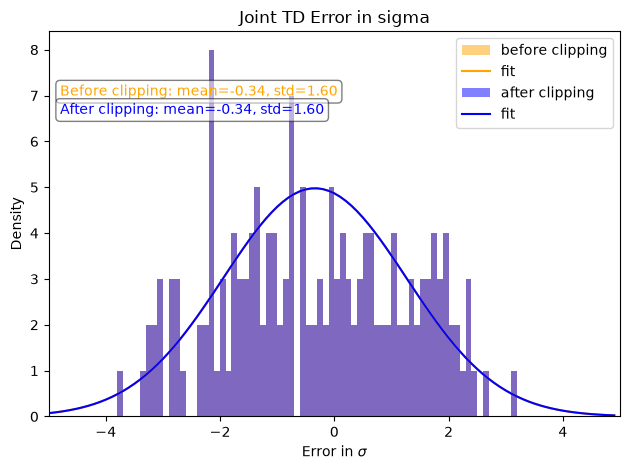

In [91]:
# instead of just taking the zeroth element of the error_in_sigma_signed array, we can plot the histogram of all three time delays
import matplotlib.pyplot as plt 
# fit a gaussian to the histogram
from scipy.stats import norm
values = td_joint_clipped['error_in_sigma_signed'].apply(lambda x: np.array(x)).explode().to_numpy(dtype=float)
values = values[~np.isnan(values)]
_, bins, _ = plt.hist(values, bins=np.arange(-5, 5, 0.1), alpha=0.5, label='before clipping',  color='orange');
param = norm.fit(values);
plt.plot(np.arange(-5, 5, 0.1), 20*norm.pdf(np.arange(-5, 5, 0.1), *param), label='fit', color='orange');
sigma = 4
mask = (values < sigma) & (values > -sigma)
plt.hist(values[mask], bins=bins, alpha=0.5, label='after clipping', color='blue');
param = norm.fit(values[mask]);
plt.plot(np.arange(-5, 5, 0.1), 20*norm.pdf(np.arange(-5, 5, 0.1), *param), label='fit', color='blue');
# in blue and yellow add text with the mean and std of the fit in a box
plt.text(-4.8, 7, f"Before clipping: mean={np.mean(values):.2f}, std={np.std(values):.2f}", bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), color='orange') 
plt.text(-4.8, 6.6, f"After clipping: mean={np.mean(values[mask]):.2f}, std={np.std(values[mask]):.2f}", bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), color='blue')
plt.xlabel('Error in $\sigma$')
plt.ylabel('Density')
plt.xlim(-5, 5)
plt.title('Joint TD Error in sigma')
plt.legend()
plt.tight_layout()

In [92]:
colors = {'u': '#1600ea', 'g': '#31de1f', 'r': '#b52626', 'i': '#370201', 'z': '#ba52ff', 'y': '#61a2b3'}


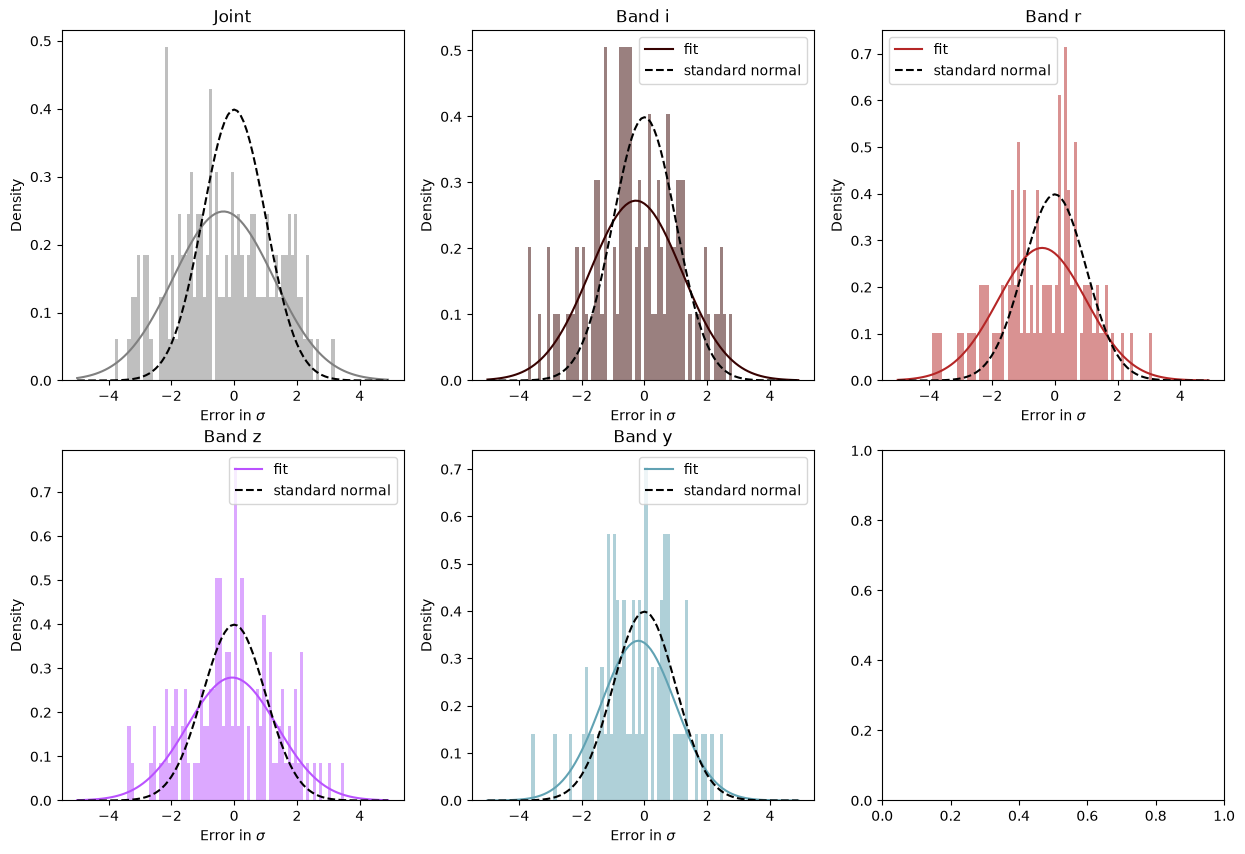

In [93]:
# make a figure with 5 subpanels, one for each band and one for the joint
# each subpanel should have a histogram of the error in sigma for that band, with a gaussian fit and the mean and std of the fit in a box
# also plot a standard normal gaussian
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()
values = td_joint_clipped['error_in_sigma_signed'].apply(lambda x: np.array(x)).explode().to_numpy(dtype=float)
values = values[~np.isnan(values)]
_, bins, _ = ax[0].hist(values, bins=np.arange(-5, 5, 0.1), alpha=0.5, density=True, color='gray');
param = norm.fit(values);
ax[0].plot(np.arange(-5, 5, 0.1), norm.pdf(np.arange(-5, 5, 0.1), *param), label='fit', color='gray');

# plot a standard normal gaussian
ax[0].plot(np.arange(-5, 5, 0.1), norm.pdf(np.arange(-5, 5, 0.1), 0, 1), label='standard normal', color='black', linestyle='--');
ax[0].set_title('Joint')
ax[0].set_xlabel('Error in $\sigma$')
ax[0].set_ylabel('Density')
# now do the same for all 4 bands
bands = ['i', 'r', 'z', 'y']
for i, df in enumerate([td_i_clipped, td_r_clipped, td_z_clipped, td_y_clipped]):
    band = bands[i]
    values = df['error_in_sigma_signed'].apply(lambda x: np.array(x)).explode().to_numpy(dtype=float)
    values = values[~np.isnan(values)]
    _, bins, _ = ax[i+1].hist(values, bins=np.arange(-5, 5, 0.1), alpha=0.5, density=True, color=colors[band]);
    param = norm.fit(values);
    ax[i+1].plot(np.arange(-5, 5, 0.1), norm.pdf(np.arange(-5, 5, 0.1), *param), label='fit', color=colors[band]);
    ax[i+1].plot(np.arange(-5, 5, 0.1), norm.pdf(np.arange(-5, 5, 0.1), 0, 1), label='standard normal', color='black', linestyle='--');

    ax[i+1].set_title(f'Band {["i", "r", "z", "y"][i]}')
    ax[i+1].set_xlabel('Error in $\sigma$')
    ax[i+1].set_ylabel('Density')
    ax[i+1].legend()

#### what is the distribution of time-delays

1. look at the distribution of true time-delays
2. look at the distribution of measured time-delays
3. look at the distribution of values sampled from a gaussian centered on the truth with LSST measurement uncertainty
4. look at the trend for error (in sigma) vs # of observations, SNR, image separation

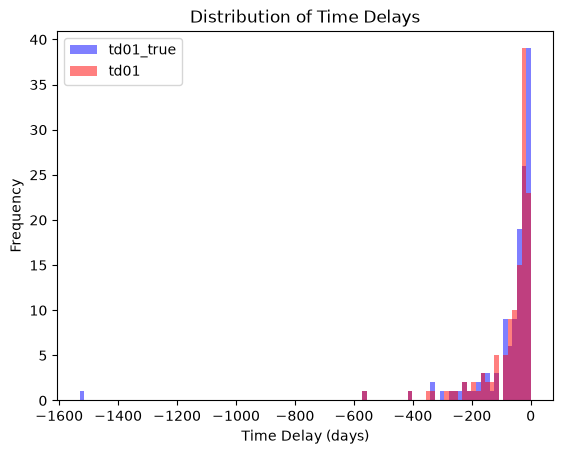

In [94]:
_, bins, _ = plt.hist(td_joint_clipped['td01_true'], np.linspace(np.min(td_joint_clipped['td01_true']), np.max(td_joint_clipped['td01_true']), 100), alpha=0.5, label='td01_true', color='blue')
plt.hist(td_joint_clipped['td01'], bins=bins, alpha=0.5, label='td01', color='red')

plt.xlabel('Time Delay (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Delays')
plt.legend()

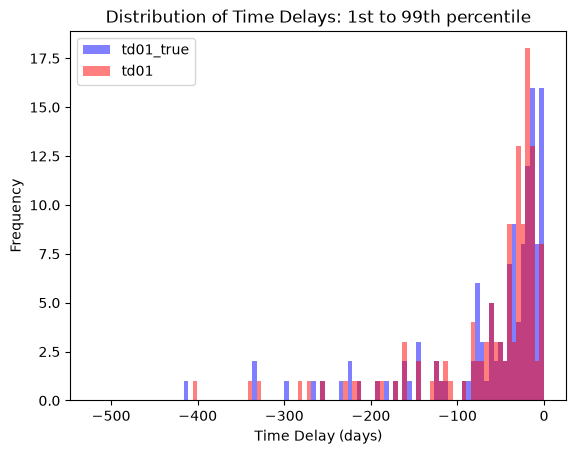

In [95]:
_, bins, _ = plt.hist(td_joint_clipped['td01_true'], np.linspace(np.percentile(td_joint_clipped['td01_true'], 1), np.percentile(td_joint_clipped['td01_true'], 99), 100), alpha=0.5, label='td01_true', color='blue')
plt.hist(td_joint_clipped['td01'], bins=bins, alpha=0.5, label='td01', color='red')

plt.xlabel('Time Delay (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Delays: 1st to 99th percentile')
plt.legend()

In [96]:
td_joint_clipped

,cov_scaled,td01,td02,td03,prec_scaled,catalog_idx,td01_true,td02_true,td03_true,uncertainty,relative_uncertainty,relative_error,error_in_sigma,error,error_in_sigma_signed
0,[[30.937899029270522]],-46.804751,NaN,NaN,[[0.03232281542628006]],deblcdouble653,-43.841759,NaN,NaN,"[5.562184735269993, nan, nan]",0.126870,"[0.06758380170353065, nan, nan]","[0.5327030397241705, nan, nan]","[-2.962992715985706, nan, nan]","[-0.5327030397241705, nan, nan]"
1,"[[6.5535240996410895, 4.253730034805673, 4.280...",-56.351601,-64.582261,-63.265716,"[[0.2428547601244266, -0.068875084626094, -0.0...",deblcquad134,-60.424795,-67.846857,-68.353976,"[2.559985175668228, 3.5764643288159013, 3.5705...",0.042366,"[0.06740931681583974, 0.04811712231570363, 0.0...","[1.5911006700544685, 0.9127996805179097, 1.425...","[4.073194128335224, 3.264595496726855, 5.08826...","[1.5911006700544685, 0.9127996805179097, 1.425..."
2,[[14.823162899949745]],-22.657524,NaN,NaN,[[0.06746198545813663]],deblcdouble91,-18.445097,NaN,NaN,"[3.8500860899400347, nan, nan]",0.208732,"[0.22837653818615958, nan, nan]","[1.0941124932724957, nan, nan]","[-4.212427291178045, nan, nan]","[-1.0941124932724957, nan, nan]"
4,[[25.393605319287804]],-17.987086,NaN,NaN,[[0.03937999301109269]],deblcdouble23,-26.201463,NaN,NaN,"[5.039206814498469, nan, nan]",0.192325,"[0.313508332529872, nan, nan]","[1.6300932512991788, nan, nan]","[8.214377020214787, nan, nan]","[1.6300932512991788, nan, nan]"
6,[[0.7460910482187403]],-14.424669,NaN,NaN,[[1.3403189897365158]],deblcdouble112,-14.414341,NaN,NaN,"[0.8637656211141655, nan, nan]",0.059924,"[0.0007165575056313009, nan, nan]","[0.011957762212237067, nan, nan]","[-0.010328703904388448, nan, nan]","[-0.011957762212237067, nan, nan]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,[[28.838204462965848]],-19.705418,NaN,NaN,[[0.03467622269216534]],deblcdouble553,-9.310776,NaN,NaN,"[5.37012145700317, nan, nan]",0.576764,"[1.116409948349895, nan, nan]","[1.9356438366157926, nan, nan]","[-10.394642500126405, nan, nan]","[-1.9356438366157926, nan, nan]"
144,[[12.2932303439592]],-11.971402,NaN,NaN,[[0.08134558387180896]],deblcdouble469,-4.653655,NaN,NaN,"[3.506170324436507, nan, nan]",0.753423,"[1.5724731694686125, nan, nan]","[2.087105514763143, nan, nan]","[-7.317747419830312, nan, nan]","[-2.087105514763143, nan, nan]"
145,"[[0.7089539481166004, 0.35554943130777467, 0.3...",-0.234191,-0.679528,-0.647593,"[[1.9445984486500398, -1.0517527236185031, -0....",deblcquad421,-0.348930,-0.687473,-2.241429,"[0.8419940309269421, 0.8068869389210885, 3.178...",2.413074,"[0.3288305145473497, 0.011557477766168051, 0.7...","[0.13627035810787486, 0.00984705112311077, 0.5...","[0.11473882811910746, 0.007945456938126316, 1....","[0.13627035810787486, 0.00984705112311077, 0.5..."
146,"[[1.5453765112266793, 0.8543396757412436, 0.82...",-0.872088,-2.808275,-6.164830,"[[0.8725561456648037, -0.2434235846254395, -0....",deblcquad285,-1.674040,-2.663371,-3.905896,"[1.243131735266492, 1.5873884159044085, 1.7727...",0.742594,"[0.47905205429966297, 0.05440613566735773, 0.5...","[0.6451064938778416, 0.09128436652422336, 1.27...","[0.8019523551660438, -0.14490374597372435, -2....","[0.6451064938778416, -0.09128436652422336, -1...."


In [97]:
# sample from a multivariate normal with the provided covariance matrix
truth = td_joint_clipped[['td01_true', 'td02_true', 'td03_true']].to_numpy()
covariances = td_joint_clipped[['cov_scaled']].to_numpy()
sampled_means = []
for i in range(len(covariances)):
    # drop nans from truth array
    truth_i = truth[i][~np.isnan(truth[i])]
    print("truth[i]:", truth_i)
    print("covariances[i][0]:", covariances[i][0])
    sampled_mean = np.random.multivariate_normal(mean=truth_i, cov=covariances[i][0])
    sampled_means.append(sampled_mean)
sampled_means


truth[i]: [-43.84175855]
covariances[i][0]: [[30.93789903]]
truth[i]: [-60.42479468 -67.84685658 -68.3539762 ]
covariances[i][0]: [[ 6.5535241   4.25373003  4.28016326]
 [ 4.25373003 12.7910971   2.17966723]
 [ 4.28016326  2.17966723 12.74871246]]
truth[i]: [-18.44509653]
covariances[i][0]: [[14.8231629]]
truth[i]: [-26.20146314]
covariances[i][0]: [[25.39360532]]
truth[i]: [-14.41434054]
covariances[i][0]: [[0.74609105]]
truth[i]: [-31.85809092]
covariances[i][0]: [[13.55883563]]
truth[i]: [-23.71033802]
covariances[i][0]: [[5.02341461]]
truth[i]: [-76.50920199]
covariances[i][0]: [[9.94441311]]
truth[i]: [ -2.59688517  -2.90001001 -18.32181639]
covariances[i][0]: [[12.77500605  2.73818684 11.30605532]
 [ 2.73818684 13.05175462 10.31922044]
 [11.30605532 10.31922044 46.36104879]]
truth[i]: [-15.69098777]
covariances[i][0]: [[23.47434701]]
truth[i]: [-73.91522887]
covariances[i][0]: [[14.10752304]]
truth[i]: [-79.29703606]
covariances[i][0]: [[592.40087542]]
truth[i]: [-13.47673756]
co

[array([-39.50041367]),
 array([-56.87277641, -61.5959157 , -67.41479437]),
 array([-12.18953206]),
 array([-17.46684383]),
 array([-14.21052958]),
 array([-38.89023391]),
 array([-23.62212731]),
 array([-76.35976742]),
 array([ -6.47775712,  -4.42531512, -21.72731379]),
 array([-10.92189675]),
 array([-65.41531922]),
 array([-75.36109272]),
 array([-12.83336683]),
 array([-20.63710834]),
 array([-19.39035051]),
 array([-14.79868044]),
 array([-12.82637422]),
 array([-26.03802221]),
 array([-64.15269915]),
 array([-224.48441111]),
 array([ -61.36205661,  -93.13035732, -124.99417971]),
 array([-96.13296192]),
 array([-34.78213378]),
 array([-40.8959227]),
 array([-14.8197434]),
 array([-12.64172369]),
 array([-327.89629688]),
 array([-147.56492156]),
 array([-60.84600022]),
 array([-222.37945022]),
 array([-11.97247488]),
 array([-78.59035411]),
 array([-37.13025039]),
 array([-53.59784861]),
 array([-254.69154253]),
 array([-58.88107534]),
 array([-14.42391134]),
 array([-35.12392493])

In [98]:
sampled_means

[array([-39.50041367]),
 array([-56.87277641, -61.5959157 , -67.41479437]),
 array([-12.18953206]),
 array([-17.46684383]),
 array([-14.21052958]),
 array([-38.89023391]),
 array([-23.62212731]),
 array([-76.35976742]),
 array([ -6.47775712,  -4.42531512, -21.72731379]),
 array([-10.92189675]),
 array([-65.41531922]),
 array([-75.36109272]),
 array([-12.83336683]),
 array([-20.63710834]),
 array([-19.39035051]),
 array([-14.79868044]),
 array([-12.82637422]),
 array([-26.03802221]),
 array([-64.15269915]),
 array([-224.48441111]),
 array([ -61.36205661,  -93.13035732, -124.99417971]),
 array([-96.13296192]),
 array([-34.78213378]),
 array([-40.8959227]),
 array([-14.8197434]),
 array([-12.64172369]),
 array([-327.89629688]),
 array([-147.56492156]),
 array([-60.84600022]),
 array([-222.37945022]),
 array([-11.97247488]),
 array([-78.59035411]),
 array([-37.13025039]),
 array([-53.59784861]),
 array([-254.69154253]),
 array([-58.88107534]),
 array([-14.42391134]),
 array([-35.12392493])

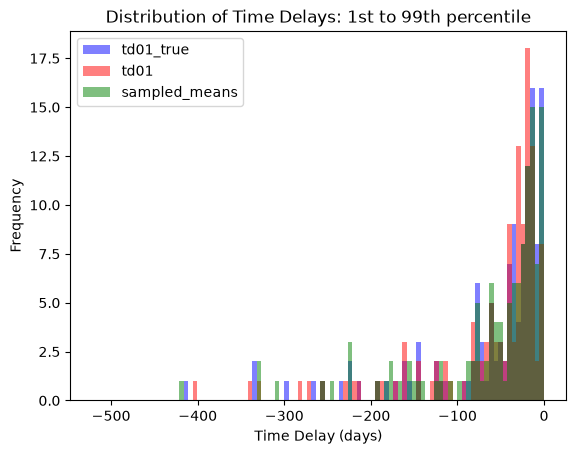

In [99]:
_, bins, _ = plt.hist(td_joint_clipped['td01_true'], np.linspace(np.percentile(td_joint_clipped['td01_true'], 1), np.percentile(td_joint_clipped['td01_true'], 99), 100), alpha=0.5, label='td01_true', color='blue')
plt.hist(td_joint_clipped['td01'], bins=bins, alpha=0.5, label='td01', color='red')
plt.hist([s[0] for s in sampled_means], bins=bins, alpha=0.5, label='sampled_means', color='green')
plt.xlabel('Time Delay (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Delays: 1st to 99th percentile')
plt.legend()

### Investigating time-delay bias

In [100]:
# Correlate time-delay errors with measurement and lens properties.
# Array-valued diagnostics are summarized per system so they can be correlated with scalar properties.
from scipy.stats import pearsonr, spearmanr


def scalar_error_properties(data):
    error = np.vstack(data['error'].to_numpy())
    error_sigma = np.vstack(data['error_in_sigma_signed'].to_numpy())
    uncertainty = np.vstack(data['uncertainty'].to_numpy())

    return pd.DataFrame({
        'error_td01': error[:, 0],
        'error_td02': error[:, 1],
        'error_td03': error[:, 2],
        'abs_error_max': np.nanmax(np.abs(error), axis=1),
        'abs_error_rms': np.sqrt(np.nanmean(error**2, axis=1)),
        'error_sigma_td01': error_sigma[:, 0],
        'error_sigma_td02': error_sigma[:, 1],
        'error_sigma_td03': error_sigma[:, 2],
        'abs_error_sigma_max': np.nanmax(np.abs(error_sigma), axis=1),
        'abs_error_sigma_rms': np.sqrt(np.nanmean(error_sigma**2, axis=1)),
        'relative_uncertainty_td01': uncertainty[:, 0] / np.abs(data['td01_true'].to_numpy()),
    }, index=data.index)


# Use the joint sample; add all numeric system properties from truth metadata.
error_properties = scalar_error_properties(td_joint_clipped)
truth_properties = merged_df.loc[td_joint_clipped.index].select_dtypes(include=np.number)
correlation_data = error_properties.join(truth_properties, how='inner')

error_columns = [
    'error_td01', 'error_td02', 'error_td03',
    'abs_error_max', 'abs_error_rms',
    'error_sigma_td01', 'error_sigma_td02', 'error_sigma_td03',
    'abs_error_sigma_max', 'abs_error_sigma_rms',
]
property_columns = [column for column in correlation_data.columns if column not in error_columns]

correlations = []
for error_column in error_columns:
    for property_column in property_columns:
        valid = correlation_data[[error_column, property_column]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) < 3 or valid[error_column].nunique() < 2 or valid[property_column].nunique() < 2:
            continue

        pearson_r, pearson_p = pearsonr(valid[error_column], valid[property_column])
        spearman_r, spearman_p = spearmanr(valid[error_column], valid[property_column])
        correlations.append({
            'error_measure': error_column,
            'property': property_column,
            'n': len(valid),
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
        })

correlations = pd.DataFrame(correlations)
correlations['abs_spearman_r'] = correlations['spearman_r'].abs()
correlations = correlations.sort_values('abs_spearman_r', ascending=False)

# Direct correlations among the signed errors and their sigma-normalized values.
error_measure_correlations_pearson = correlation_data[error_columns].corr(method='pearson')
error_measure_correlations_spearman = correlation_data[error_columns].corr(method='spearman')

display(error_measure_correlations_spearman)
display(correlations.head(30))

,error_td01,error_td02,error_td03,abs_error_max,abs_error_rms,error_sigma_td01,error_sigma_td02,error_sigma_td03,abs_error_sigma_max,abs_error_sigma_rms
error_td01,1.000000,0.532143,0.360714,-0.098994,-0.113032,0.934754,0.478571,0.407143,-0.241020,-0.249574
error_td02,0.532143,1.000000,0.514286,-0.032143,0.000000,0.557143,0.978571,0.500000,-0.264286,-0.250000
error_td03,0.360714,0.514286,1.000000,-0.507143,-0.425000,0.300000,0.446429,0.700000,-0.442857,-0.364286
abs_error_max,-0.098994,-0.032143,-0.507143,1.000000,0.989870,-0.095979,-0.064286,-0.192857,0.719545,0.715342
abs_error_rms,-0.113032,0.000000,-0.425000,0.989870,1.000000,-0.107553,-0.032143,-0.189286,0.705961,0.722753
error_sigma_td01,0.934754,0.557143,0.300000,-0.095979,-0.107553,1.000000,0.517857,0.342857,-0.261449,-0.265433
error_sigma_td02,0.478571,0.978571,0.446429,-0.064286,-0.032143,0.517857,1.000000,0.457143,-0.282143,-0.282143
error_sigma_td03,0.407143,0.500000,0.700000,-0.192857,-0.189286,0.342857,0.457143,1.000000,-0.750000,-0.732143
abs_error_sigma_max,-0.241020,-0.264286,-0.442857,0.719545,0.705961,-0.261449,-0.282143,-0.750000,1.000000,0.984575
abs_error_sigma_rms,-0.249574,-0.250000,-0.364286,0.715342,0.722753,-0.265433,-0.282143,-0.732143,0.984575,1.000000


,error_measure,property,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r
902,error_td03,y_uncertainty,4,-0.968035,0.031965,-1.000000,0.000000,1.000000
574,error_td02,r_uncertainty,7,-0.702768,0.078215,-0.785714,0.036238,0.785714
947,error_td03,point_source_parameters_mag_pert_1,15,-0.450678,0.091807,-0.778571,0.000627,0.778571
431,error_td02,extended_source_light_i_magnitude,15,-0.579249,0.023644,-0.764286,0.000907,0.764286
495,error_td02,extended_unlensed_mag,15,-0.579249,0.023644,-0.764286,0.000907,0.764286
601,error_td02,source_parameters_mag_app,15,-0.579249,0.023644,-0.764286,0.000907,0.764286
2068,error_sigma_td02,extended_source_light_i_magnitude,15,-0.610798,0.015575,-0.757143,0.001081,0.757143
2132,error_sigma_td02,extended_unlensed_mag,15,-0.610798,0.015575,-0.757143,0.001081,0.757143
2238,error_sigma_td02,source_parameters_mag_app,15,-0.610798,0.015575,-0.757143,0.001081,0.757143
2049,error_sigma_td02,extended_source_light_r_magnitude,15,-0.627698,0.012236,-0.725000,0.002227,0.725000


In [101]:
# Mixed doubles/quads correlations, grouped by physical property and source table.
# Doubles use td01; quads use the component with the largest absolute error.
from scipy.stats import pearsonr, spearmanr


def select_td_error(data):
    errors = np.asarray(data['error'].tolist(), dtype=float)
    errors_sigma = np.asarray(data['error_in_sigma_signed'].tolist(), dtype=float)
    is_quad = data['catalog_idx'].str.contains('quad', na=False).to_numpy()
    row_indices = np.arange(len(data))

    worst_error_component = np.nanargmax(np.abs(errors), axis=1)
    worst_sigma_component = np.nanargmax(np.abs(errors_sigma), axis=1)
    error_component = np.where(is_quad, worst_error_component, 0)
    sigma_component = np.where(is_quad, worst_sigma_component, 0)

    return pd.DataFrame({
        'selected_error': errors[row_indices, error_component],
        'selected_error_in_sigma': errors_sigma[row_indices, sigma_component],
        'selected_component': np.where(is_quad, worst_error_component + 1, 1),
        'is_quad': is_quad,
    }, index=data.index)


def canonical_property_name(column):
    """Normalize common aliases without merging unrelated measurements."""
    name = re.sub(r'_(?:x|y)$', lambda match: match.group(0), str(column).lower())
    name = re.sub(r'(^|_)parameters_', r'\1', name)
    name = name.replace('main_deflector_', 'deflector_')
    name = name.replace('deflector_mass_', 'deflector_')
    name = re.sub(r'_+', '_', name).strip('_')
    return name


def grouped_numeric_properties(frame, key, requested_keys, source_name, index):
    lookup = frame.drop_duplicates(key).set_index(key)
    source = lookup.reindex(requested_keys).copy()
    source.index = index
    numeric = source.select_dtypes(include=np.number)
    excluded = {'td01', 'td02', 'td03', 'catalog_idx'}
    numeric = numeric.drop(columns=[column for column in excluded if column in numeric], errors='ignore')

    groups = {}
    for column in numeric.columns:
        groups.setdefault(canonical_property_name(column), []).append(column)

    grouped_columns = {}
    aliases = []
    for canonical_name, columns in groups.items():
        # Coalesce aliases row-wise; this also handles aliases with different NaN patterns.
        grouped_columns[f'{source_name}:{canonical_name}'] = numeric[columns].bfill(axis=1).iloc[:, 0]
        aliases.append({
            'source': source_name,
            'property_group': canonical_name,
            'columns': ', '.join(columns),
            'n_aliases': len(columns),
        })
    return pd.DataFrame(grouped_columns, index=index), pd.DataFrame(aliases)


selected_errors = select_td_error(td_joint_clipped)
sample = merged_df.loc[td_joint_clipped.index]

# Keep df_truth and padma_truth separate, while aligning both to the same selected systems.
df_truth_properties, df_truth_aliases = grouped_numeric_properties(
    df_truth,
    key='catalog_idx',
    requested_keys=sample['catalog_idx'].to_numpy(),
    source_name='df_truth',
    index=sample.index,
)
padma_truth_properties, padma_truth_aliases = grouped_numeric_properties(
    padma_truth,
    key='dataset',
    requested_keys=sample['dataset'].to_numpy(),
    source_name='padma_truth',
    index=sample.index,
)

source_properties = {
    'df_truth': df_truth_properties,
    'padma_truth': padma_truth_properties,
}
all_aliases = pd.concat([df_truth_aliases, padma_truth_aliases], ignore_index=True)


def calculate_correlations(properties, source_name):
    correlation_data = selected_errors.join(properties, how='inner')
    error_columns = ['selected_error', 'selected_error_in_sigma']
    property_columns = list(properties.columns)
    results = []

    for error_column in error_columns:
        for property_column in property_columns:
            valid = correlation_data[[error_column, property_column]].replace(
                [np.inf, -np.inf], np.nan
            ).dropna()
            if len(valid) < 3 or valid[error_column].nunique() < 2 or valid[property_column].nunique() < 2:
                continue

            pearson_r, pearson_p = pearsonr(valid[error_column], valid[property_column])
            spearman_r, spearman_p = spearmanr(valid[error_column], valid[property_column])
            results.append({
                'source': source_name,
                'error_measure': error_column,
                'property_group': property_column.split(':', 1)[1],
                'n': len(valid),
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p,
            })

    result = pd.DataFrame(results)
    result['abs_spearman_r'] = result['spearman_r'].abs()
    return result.sort_values('abs_spearman_r', ascending=False)


df_truth_correlations = calculate_correlations(df_truth_properties, 'df_truth')
padma_truth_correlations = calculate_correlations(padma_truth_properties, 'padma_truth')

print(selected_errors['is_quad'].value_counts().rename({True: 'quads', False: 'doubles'}))
print('Grouped aliases:')
display(all_aliases[all_aliases['n_aliases'] > 1])
print('Correlations with df_truth properties:')
display(df_truth_correlations.head(30))
print('Correlations with padma_truth properties:')
display(padma_truth_correlations.head(30))

is_quad
doubles    118
quads       15
Name: count, dtype: int64
Grouped aliases:


,source,property_group,columns,n_aliases


Correlations with df_truth properties:


,source,error_measure,property_group,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r
39,df_truth,selected_error,point_source_magnification_2,15,0.307176,0.265418,0.678571,0.005417,0.678571
104,df_truth,selected_error_in_sigma,point_source_magnification_2,15,0.398352,0.141385,0.521429,0.046219,0.521429
37,df_truth,selected_error,point_source_x_image_2,15,-0.025822,0.927216,-0.342857,0.210924,0.342857
93,df_truth,selected_error_in_sigma,point_source_lens_ps_offset,133,0.236405,0.006152,0.287484,0.000793,0.287484
128,df_truth,selected_error_in_sigma,fpd03,15,-0.026957,0.924026,0.278571,0.314709,0.278571
107,df_truth,selected_error_in_sigma,point_source_y_image_3,15,-0.327340,0.233668,-0.271429,0.327789,0.271429
28,df_truth,selected_error,point_source_lens_ps_offset,133,0.103633,0.235199,0.270871,0.001613,0.270871
126,df_truth,selected_error_in_sigma,fpd01,133,-0.195759,0.023934,-0.263974,0.002139,0.263974
102,df_truth,selected_error_in_sigma,point_source_x_image_2,15,-0.136772,0.626928,-0.250000,0.368846,0.250000
61,df_truth,selected_error,fpd01,133,-0.150969,0.082815,-0.244606,0.004546,0.244606


Correlations with padma_truth properties:


,source,error_measure,property_group,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r
221,padma_truth,selected_error,point_source_magnification_2,15,0.127055,0.651824,0.596429,0.018932,0.596429
481,padma_truth,selected_error_in_sigma,point_source_magnification_2,15,0.296846,0.282646,0.489286,0.064160,0.489286
256,padma_truth,selected_error,shear_2,15,0.177338,0.527202,0.489286,0.064160,0.489286
228,padma_truth,selected_error,micro_shear_2,15,0.177338,0.527202,0.489286,0.064160,0.489286
504,padma_truth,selected_error_in_sigma,cd_true,15,-0.339175,0.216188,-0.446429,0.095293,0.446429
480,padma_truth,selected_error_in_sigma,image_2_arrival_time,15,0.344868,0.208083,0.439286,0.101361,0.439286
244,padma_truth,selected_error,cd_true,15,0.195614,0.484752,-0.403571,0.135768,0.403571
494,padma_truth,selected_error_in_sigma,max_delay,133,0.128312,0.141051,0.392870,0.000003,0.392870
234,padma_truth,selected_error,max_delay,133,0.091006,0.297509,0.387335,0.000004,0.387335
421,padma_truth,selected_error_in_sigma,point_source_arrival_time_1,133,0.129124,0.138532,0.381204,0.000006,0.381204
